<a href="https://colab.research.google.com/github/AshwaniPratap61/Homicide-1980-2014-Exploratory-Data-Analysis-V-1/blob/main/Homicide_Cleaning_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Homicide EDA (1980-2014)**

***About Homicide:***  
Homicide is the unlawful killing of one person by another. It includes criminal acts such as murder and non-negligent manslaughter, where the death is caused intentionally or through serious criminal behavior. Homicide statistics are widely used by law enforcement agencies, governments, and researchers to understand crime patterns, identify high-risk areas, evaluate public safety policies, and improve crime prevention strategies.


---


**_Dataset :_**  
This dataset includes murders from the FBI's Supplementary Homicide Report from 1976 to the present and Freedom of Information Act data on more than 22,000 homicides that were not reported to the Justice Department. This dataset includes the age, race, sex, ethnicity of victims and perpetrators, in addition to the relationship between the victim and perpetrator and weapon used.

- _This DataSet is taken from the Kaggle and data usibility rating is 6.7/10_
- _The Original Data contain about 638454 rows and 18 columns._  
- _This dataset information around 1574 cities._


---



***Objective:***  
Analysie the crime trends across the different regions, involment of the organisations, and geographic crime patterns between 1980-2014.



---



**_Columns Report:_**  
    Data set has 18 columns which reperesents the basic information about the crime, victim and the perpetrator.

1.  `Record ID` It represents the Id number of the cases.
3. `Agency Name` Name of the Agency.
4. `Agency Type` Type of Agency. [**Municipal Police, Sheriff, Country Police, State Police, Special Police, Regional Police, Tribal Police**]

5. `City` Cities where crime occured.
6. `State` State name.
7. `Year` Year when crime happened.
8. `Month` Month when crime happened it could be also possible that in the same
month multiple crime were occured.
9. `Incident` Incident number reported at that time priod e.g month, year.
10. `Crime Type` Type of crime done by the Accused eg. Murder, Thef, Violation of Rules.
11. `Crime Solved` Case outcome solved or not (Yes, NO)
12. `Victoms sex`
13. `Victim Age`
14. `Perpetrator Sex`
15. `Perpetrator Age`
16. `Relationship` Accused relationship with Victim eg. Family member, Friend, Neighbor etc.
17. `Weapon` Weapon involved to carry out crime eg. Knife, Gun, Any sharp object etc.
18. `Victim Count`
19. `Perpetrator Count`

### Coustom Function

In [ ]:
def countplot_with_percentage(data, x, figsize=(8, 5)):
    plt.figure(figsize=figsize)

    ax = sns.countplot(data=data, x=x)

    total = len(data)

    for p in ax.patches:
        percentage = p.get_height() / total * 100
        ax.annotate(
            f"{percentage:.1f}%",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

In [ ]:
#import labraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# styling
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook",
    font_scale=0.8
)
plt.rcParams["figure.figsize"] = (5,4)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

In [ ]:
#load dataSet
df= pd.read_csv('/content/drive/MyDrive/HomocideReport/database.csv/databaseSelected.csv')

#droping null columns
df.drop(columns=['Unnamed: 1', 'Unnamed: 13', 'Unnamed: 14','Unnamed: 17', 'Unnamed: 18', 'Record ID'], inplace= True)

/tmp/ipykernel_406/2826554402.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('/content/drive/MyDrive/HomocideReport/database.csv/databaseSelected.csv')


# 1. Data Assessment

In [ ]:
print(f'There are in total {df.columns.shape[0]} columns. \n{df.columns}')

There are in total 17 columns. 
Index(['Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month',
       'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age',
       'Perpetrator Sex', 'Perpetrator Age', 'Relationship', 'Weapon',
       'Victim Count', 'Perpetrator Count'],
      dtype='object')


In [ ]:
df.sample(5)
df.head()

,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,Crime Solved,Victim Sex,Victim Age,Perpetrator Sex,Perpetrator Age,Relationship,Weapon,Victim Count,Perpetrator Count
0,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,Yes,Male,14,Male,15,Acquaintance,Blunt Object,0,0
1,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,Yes,Male,43,Male,42,Acquaintance,Strangulation,0,0
2,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,No,Female,30,Unknown,0,Unknown,Unknown,0,0
3,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,Yes,Male,43,Male,42,Acquaintance,Strangulation,0,0
4,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,No,Female,30,Unknown,0,Unknown,Unknown,0,1


In [ ]:
print(f'Total number of rows - {df.shape[0]}\n Total number of features/columns - {df.shape[1]}')

Total number of rows - 638454
 Total number of features/columns - 17


In [ ]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Agency Name        638454 non-null  object
 1   Agency Type        638454 non-null  object
 2   City               638454 non-null  object
 3   State              638454 non-null  object
 4   Year               638454 non-null  int64 
 5   Month              638454 non-null  object
 6   Incident           638454 non-null  int64 
 7   Crime Type         638454 non-null  object
 8   Crime Solved       638454 non-null  object
 9   Victim Sex         638454 non-null  object
 10  Victim Age         638454 non-null  int64 
 11  Perpetrator Sex    638454 non-null  object
 12  Perpetrator Age    638454 non-null  object
 13  Relationship       638454 non-null  object
 14  Weapon             638454 non-null  object
 15  Victim Count       638454 non-null  int64 
 16  Perpetrator Count  6

,count,mean,std,min,25%,50%,75%,max
Year,638454.0,1995.801102,9.927693,1980.0,1987.0,1995.0,2004.0,2014.0
Incident,638454.0,22.967924,92.149821,0.0,1.0,2.0,10.0,999.0
Victim Age,638454.0,35.033512,41.628306,0.0,22.0,30.0,42.0,998.0
Victim Count,638454.0,0.123334,0.537733,0.0,0.0,0.0,0.0,10.0
Perpetrator Count,638454.0,0.185224,0.585496,0.0,0.0,0.0,0.0,10.0


In [ ]:
df.duplicated().value_counts()  #1898 duplicates

,count
False,636556
True,1898


In [ ]:
df.isna().sum()

,0
Agency Name,0
Agency Type,0
City,0
State,0
Year,0
Month,0
Incident,0
Crime Type,0
Crime Solved,0
Victim Sex,0


## **1.1 Inital Observstions -**

**_Facts_**
- The data set contains 638454 records and 17 features.
- No Null values present in data.
- `Perpetrator Age` has the dtype of object rather than int.
- Data contains aobut 1898  of duplicate rows.
- `Victim Age` has the max age value of 998.
- `Incident` column has the max value of 999.



---


**_Interpritation_**
- **Although NUll values dosent exist in dataset but placeholders are used for the unavailabel information -**
  - **For the categorical column 'Unknown' is assigned.**
  - **And for specific numerical columns like `Victim Age` and `Perpetrator Age` '0' is assigned for missing values rather than representing a real data.**
- `Incident` max value 999 could be real data of typo error. This will be addressed later in the cleaning.

# 2. Cleaning

In [ ]:
#creating a new copy of data
ndf = df.copy()

In [ ]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Agency Name        638454 non-null  object
 1   Agency Type        638454 non-null  object
 2   City               638454 non-null  object
 3   State              638454 non-null  object
 4   Year               638454 non-null  int64 
 5   Month              638454 non-null  object
 6   Incident           638454 non-null  int64 
 7   Crime Type         638454 non-null  object
 8   Crime Solved       638454 non-null  object
 9   Victim Sex         638454 non-null  object
 10  Victim Age         638454 non-null  int64 
 11  Perpetrator Sex    638454 non-null  object
 12  Perpetrator Age    638454 non-null  object
 13  Relationship       638454 non-null  object
 14  Weapon             638454 non-null  object
 15  Victim Count       638454 non-null  int64 
 16  Perpetrator Count  6

In [ ]:
ndf['Perpetrator Age'].unique()

array([15, 42, 0, 36, 27, 35, 40, 49, 39, 29, 19, 23, 33, 26, 41, 28, 61,
       25, 7, 17, 34, 21, 43, 38, 66, 32, 37, 22, 30, 24, 65, 51, 60, 45,
       64, 18, 20, 44, 73, 62, 69, 52, 16, 90, 56, 47, 57, 31, 46, 14, 55,
       50, 54, 68, 77, 53, 67, 48, 76, 58, 71, 63, 89, 13, 75, 72, 93, 59,
       10, 11, 79, 74, 99, 70, 78, 80, 9, 12, 81, 6, 87, 82, 83, 8, 84,
       85, 86, 5, 3, 1, 88, 95, 4, 91, 92, 96, 94, 2, 98, 97, '22', '52',
       '21', '0', '25', '61', '32', '28', '20', '38', '18', '17', '53',
       '30', '24', '84', '43', '16', '47', '54', '50', '42', '23', '36',
       '35', '60', '27', '19', '14', '57', '63', '81', '31', '58', '51',
       '15', '40', '33', '26', '41', '29', '34', '37', '69', '44', '48',
       '55', '49', '56', '39', '45', '65', '59', '70', '46', '11', '77',
       '67', '76', '85', '72', '13', '89', '74', '71', '64', '62', '3',
       '80', '73', '75', '83', '78', '68', '66', '86', '87', '95', '90',
       '6', '12', '99', '88', '9', '93', '10', 

**Problem 1 -**  
* `Perpetrator Age` has the dtype as Object.
* This column also has the alpha numeric data entries e.g. 22, '31'.
* Due to mixed datatype and Object dtype later it could be problematic duirng EDA.

In [ ]:
#problem
print(f'dtype: {ndf['Perpetrator Age'].dtype}')

dtype: object


In [ ]:
#solution
ndf['Perpetrator Age']= ndf['Perpetrator Age'].astype(str).str.strip().replace('', np.nan)
ndf['Perpetrator Age']= ndf['Perpetrator Age'].astype('Int64')


In [ ]:
ndf['Perpetrator Age'].dtype

Int64Dtype()

**Solution -**  

*   Converted whole column entries to string data type to normalize the values.
*   Striped out all unnecessary spaces to prevent any value error.
*   Some of the entries has the empty string e.g. ' ' , replaced them with Null values.  
*   After normalizing the whole column converted it into Int64.



---



**Problem 2 -**  
* Data set contain about 1898 duplicate rows i.e its  0.30% of the dataset.
* This could lead to inaccurate statistical metrics, and wastage of storage.

In [ ]:
print(f'The percentage of duplicate rows is: \n {ndf.duplicated().sum()/df.shape[0]* 100:.2f}%')

The percentage of duplicate rows is: 
 0.30%


In [ ]:
#solution
ndf.drop_duplicates(inplace=True)

In [ ]:
#test
ndf.duplicated().value_counts()

,count
False,636556


**Solution -**  
* Find the toal precentage of the duplicate rows to ensure the minimum data loss.  
* Droped all the duplicated rows.


---



**Problem 3 -**  
* `Victim Age` has some of the extream entries for victim's age e.g there are 952 rows where the victim's age is mentioned 998 years.
* There could multiple values which arent represting the real world person's age.

In [ ]:
ndf[ndf['Victim Age'] == 998].shape[0]

952

In [ ]:
#solution
ndf['Victim Age'] = ndf['Victim Age'].replace(998, np.nan)
ndf['Victim Age']=ndf['Victim Age'].astype('Int64')
median_age = ndf['Victim Age'].median()
ndf['Victim Age'] = ndf['Victim Age'].fillna(median_age)


In [ ]:
#test
ndf['Victim Age'].isnull().sum()
ndf['Victim Age'].unique()


<IntegerArray>
[14, 43, 30, 42, 99, 32, 38, 36, 20, 48, 31, 16, 33, 27, 21, 60, 40, 18,  8,
 25, 24, 46, 23, 22, 45, 26, 58, 17, 29, 41, 68, 13, 35, 44, 54, 37, 51, 90,
 50, 52, 61, 63, 19, 28, 70, 72, 74, 53, 57, 76, 79, 69, 34, 66, 55, 67, 65,
 47,  1, 49, 62, 75, 56, 59, 78, 39, 15,  0, 71, 77,  2,  4, 64, 82, 85,  6,
  5,  7,  9, 84, 10, 86, 11, 73, 83, 81, 87, 80,  3, 12, 94, 93, 92, 89, 97,
 88, 91, 95, 98, 96]
Length: 100, dtype: Int64

**Solutioin -**  
* There were 952 values with age= 998, replaced all those extream values with Null.  
* Find the median of the `Victim Age` column.
* Replaced all the Null values with the median_age.

**Problem 4 -**  
* Although there no Null entries in the dataset but columns with missing information is still present. There mainly 4 columns, `Victim Age`, `Victim Sex`, `Perpetrator Age` and `Perpetrator Sex` these columns has the missing values, but the placeholders like for numerical columns  like `Victim Age` and  `Perpetrator Age` where the information is missing 0 is placed, same for categorical columns `Victim Sex`and `Perpetrator Sex` placeholder 'Unknown' is used.  


In [ ]:
#solution
mask = (
    (df['Crime Solved'] == 'No') &
    (df['Victim Age'] == 0) &
    (df['Victim Sex'] == 'Unknown') &
    (df['Perpetrator Age'] == 0) &
    (df['Perpetrator Sex'] == 'Unknown')
)
ndf = ndf[~mask]   #removing all those rows


/tmp/ipykernel_406/2160227587.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ndf = ndf[~mask]   #removing all those rows


In [ ]:
#test
ndf.shape[0]

636523

**Solution -**  
* *There are approx ~200000 rows with these placeholder, removing all of them could cost a massive data loss and could create biasness during the EDA.*  
* First filted out all those rows which full-fill these conditions -
  * 'Crime Solved' == 'No  
  * 'Victim Age' == 0  
  * 'Victim Sex' == 'Unknown'  
  * 'Perpetrator Age' == 0  
  * 'Perpetrator Sex' == 0

* If these conditions fullfills then Atuthorities dont have the any information about the case it all, means these rows dont represent any vlauable information.

In [ ]:
ndf.columns

Index(['Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month',
       'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age',
       'Perpetrator Sex', 'Perpetrator Age', 'Relationship', 'Weapon',
       'Victim Count', 'Perpetrator Count'],
      dtype='object')

**Problem 5 -**  
* Column `Victim Age` has lack of information and placeholders are used in place of real person's age e.g 0.
* Those entries need to be filled with logical values.
* These value create skewness in data and biasness while calculating mean, median.

In [ ]:
ndf['Victim Age']= ndf['Victim Age'].replace(0, np.nan)
ndf['Victim Age']= ndf['Victim Age'].fillna(ndf['Victim Age'].median())

In [ ]:
ndf['Victim Age'].describe()

,Victim Age
count,636523.0
mean,33.955772
std,17.326321
min,1.0
25%,22.0
50%,30.0
75%,42.0
max,99.0


**Solution -**
* Replaced all the placeholder values (0) with NUll.
* Filled those NUll with median of the `Victim Age`.  


---



**Probelm 6 -**  
* `Victim Count` and `Perperatror Count` represent the addition count beyond the obvious ones. Therefor i order to solve this mistake we will add the 1 in both of the columns to avoid any future inconvenience.

In [ ]:
ndf['Perpetrator Count']= ndf['Perpetrator Count']+1
ndf['Victim Count']= ndf['Victim Count']+1

**Problem 7 -**  
* `Incident` column has the dtype of int although it represents the subsequence number of case happend under a perticular judiciary.  

**Solution -**  
This column need type conversion from integer to sting/object data type.

In [ ]:
#solution
ndf['Incident'] = ndf['Incident'].astype(str)

#test
ndf['Incident'].dtype

dtype('O')

## 2.1 Data Cleaning Summary

The dataset was systematically cleaned to improve its consistency, quality, and reliability before performing exploratory data analysis.

### Cleaning Tasks Performed

* Removed leading and trailing whitespace from text columns to standardize categorical values.
* Replaced placeholder values representing missing information with appropriate missing value indicators (`NaN`) where applicable.
* Converted columns with incorrect data types (such as age stored as text) into appropriate numeric data types.
* Identified and corrected invalid age values (e.g., `998`) by treating them as missing values and imputing them using suitable statistical measures.
* Analyzed duplicate records and verified their impact on the dataset.
* Investigated the use of placeholder values such as `0` and `"Unknown"` to distinguish between genuinely missing information and meaningful coded values.
* Used the `Crime Solved` field to better understand missing perpetrator information instead of applying indiscriminate imputation.
* Identified fully incomplete unsolved cases and removed 33 records, representing approximately **0.005%** of the dataset, as they contained no meaningful analytical information.

### Outcome

The cleaned dataset is now more consistent, contains fewer data quality issues, and is better suited for reliable exploratory data analysis and subsequent modeling or statistical analysis.


---



# 3. Exploratray Data Analysis

**Columns Dsicription -**  

* ***Categorical ->*** `Agency Name `, `Agency Type`, `City`, `State`, `Month`, `Crime Type`, `Crime Solved`, `Victim Sex`, `Perpetrator Sex`, `Relationship` and `Weapon`  

* ***Numercial ->*** `Year`, `Incident`, `Victim Age`, `Perpetrator Age`, `Victim Count`, and `Perpetrator Count`

In [ ]:
ndf.head()

,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,Crime Solved,Victim Sex,Victim Age,Perpetrator Sex,Perpetrator Age,Relationship,Weapon,Victim Count,Perpetrator Count
0,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,Yes,Male,14,Male,15,Acquaintance,Blunt Object,1,1
1,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,Yes,Male,43,Male,42,Acquaintance,Strangulation,1,1
2,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,No,Female,30,Unknown,0,Unknown,Unknown,1,1
3,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,Yes,Male,43,Male,42,Acquaintance,Strangulation,1,1
4,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,No,Female,30,Unknown,0,Unknown,Unknown,1,2


## 3.1 Univariate Analysis

In [ ]:
# Agency Name
top5= ndf['Agency Name'].value_counts().sort_values(ascending=False).head()

In [ ]:
bottom5 = ndf['Agency Name'].value_counts().sort_values().head()
bottom5

,count
Agency Name,
Sp: Middlesex County,1
Powhatan County,1
Tazewell County,1
Sammamish,1
Walla Walla County,1


Text(0.5, 0.98, 'Top 5 vs Bottom 5 Agencies by reported crime cases')

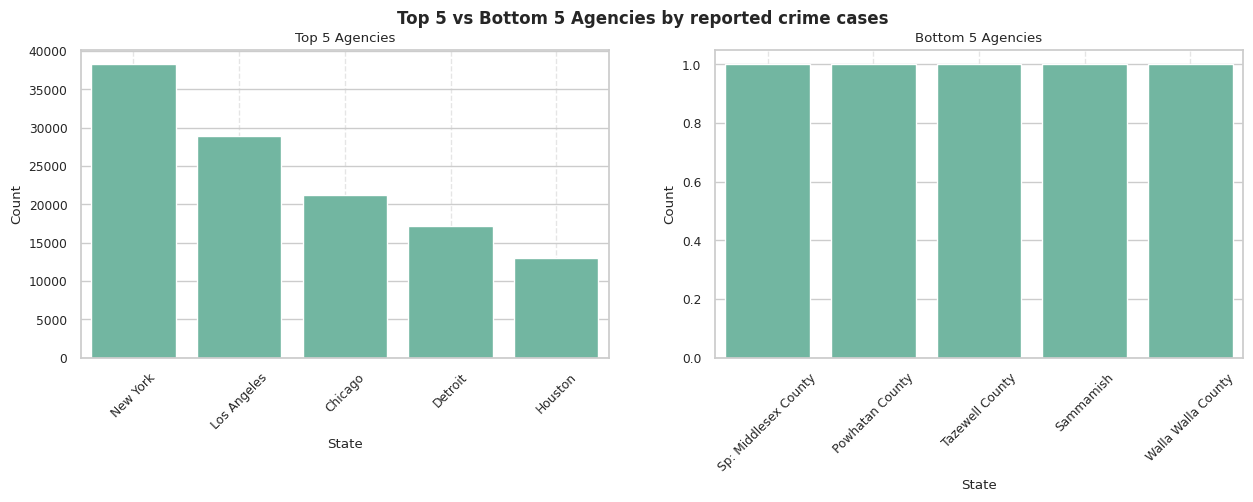

In [ ]:
fig, ax= plt.subplots(1, 2, figsize=(15,4))
sns.barplot(data=top5, ax=ax[0])
sns.barplot(data=bottom5, ax=ax[1])


title = ['Top 5 Agencies', 'Bottom 5 Agencies']
for ax, title in zip(ax, title):
    ax.set_title(title)
    ax.set_xlabel("State")
    ax.set_ylabel("Count")
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
fig.suptitle('Top 5 vs Bottom 5 Agencies by reported crime cases', fontsize= 12, fontweight = 'bold')


Text(0.5, 0.98, 'City and state distribution')

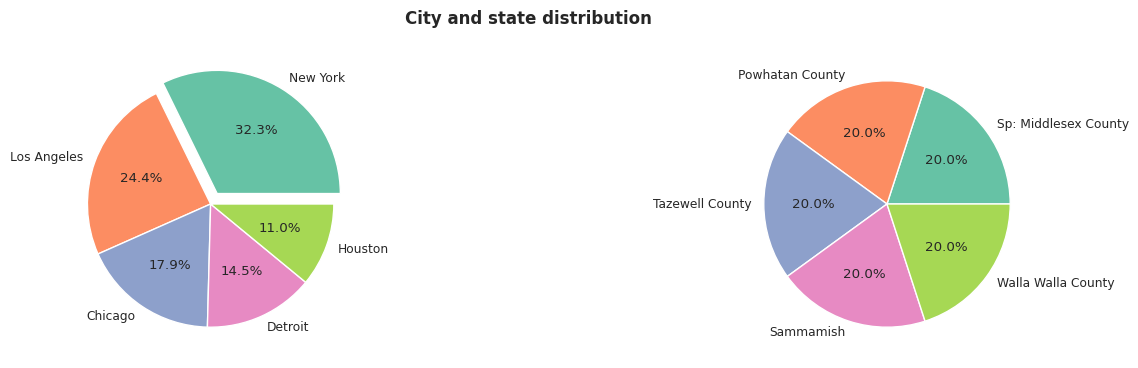

In [ ]:
fig, ax= plt.subplots(1, 2, figsize=(16,4))
ax[0].pie(top5, labels= top5.index, autopct = '%1.1f%%', explode= [0.1,0,0,0,0])
ax[1].pie(bottom5, labels= bottom5.index, autopct = '%1.1f%%')
fig.suptitle('City and state distribution', fontsize= 12, fontweight = 'bold')


**Observations -**

* In the `Agency Name` column  
    * New York - 38275
    * Los Angeles - 28935
    * Chicago - 21277
    * Detroit - 17144  and,
    * Housten - 13011  
These are the top 5 agencies and most of the cases are handled by these agencies.  

* Whereas the Agencies with least number of case involvement are-  
    * Middlesex Country - 1
    * Powhatan County - 1
    * Tazewell County - 1
    * Sammamish - 1
    * Walla Walla County - 1

**Interpritation -**  

- A possible reason is that these jurisdictions have relatively smaller populations than major metropolitan areas, which could naturally result in fewer reported incidents.
- However, this dataset alone cannot confirm that population size is the cause.

---



Text(0.5, 0.98, 'Cities and States by Reported crimes')

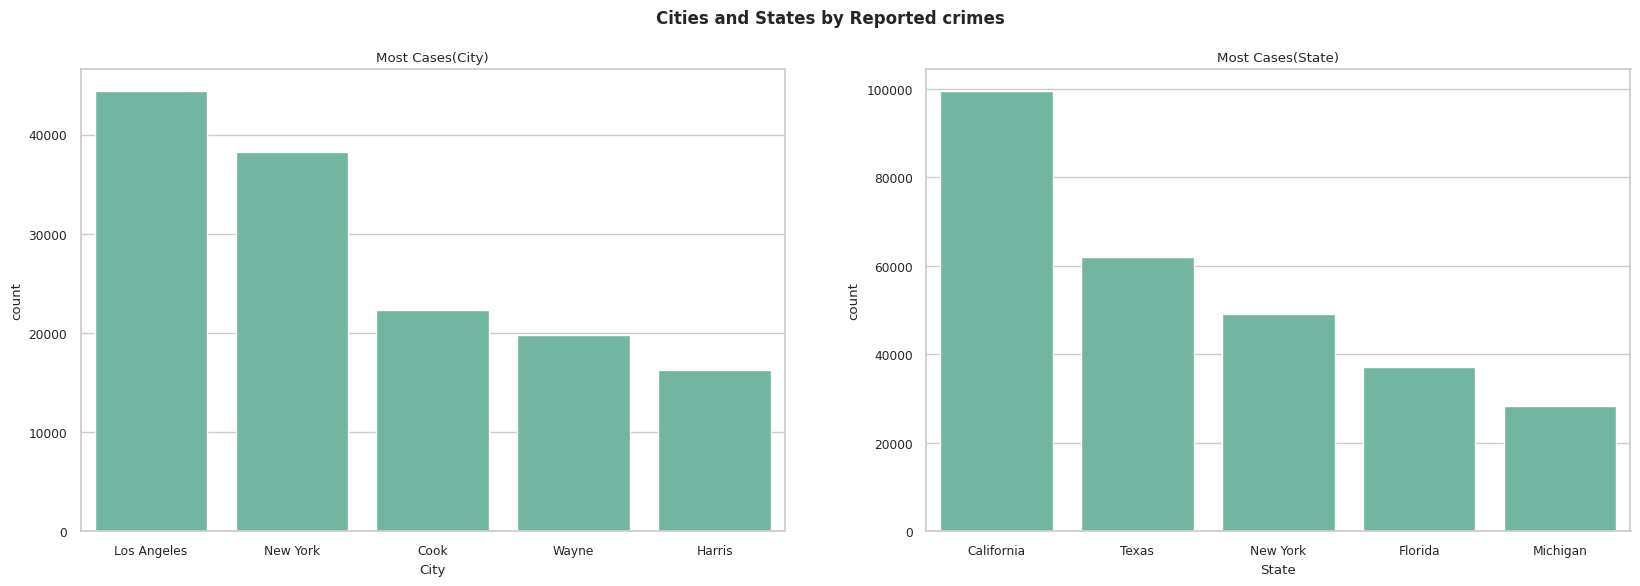

In [ ]:
#City and State
top_city = ndf['City'].value_counts().sort_values(ascending=False).head()
top_state = ndf['State'].value_counts().sort_values(ascending=False).head()


fig, ax= plt.subplots(1, 2, figsize=(20,6))
sns.barplot(data=top_city, ax=ax[0])
sns.barplot(data=top_state, ax=ax[1])

title = ['Most Cases(City)', 'Most Cases(State)']
for ax, title in zip(ax, title):
    ax.set_title(title)
fig.suptitle('Cities and States by Reported crimes', fontsize= 12, fontweight = 'bold')


***Observation :***  
* The top 5 Cities with most reported Cases are -
    * Los Angeles
    * New York
    * Cook City
    * Wayne
    * Harris

* Where as if take a brief look at the States -
    * California
    * Taxas
    * New York
    * Florida
    * Michigan

Text(0.5, 1.0, 'Year by Reported crimes')

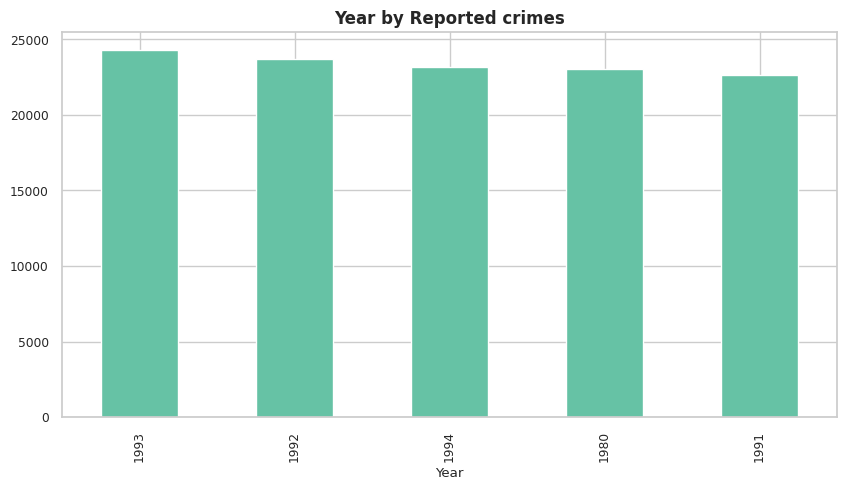

In [ ]:
#Year
plt.figure(figsize=(10,5))
ndf['Year'].value_counts().sort_values(ascending= False).head().plot(kind= 'bar')
plt.title('Year by Reported crimes', fontsize= 12, fontweight = 'bold')


* 1993 was the peak where most of the crimes happen

In [ ]:
ndf['Crime Type'].unique()
ndf['Crime Type'].value_counts()

,count
Crime Type,
Murder or Manslaughter,627441
Manslaughter by Negligence,9082


Here only two types of crimes are recorded  
* Murder or Manslaughter with 627441 reportd cases and  
* Manslaughter by Negligence with the 9082 reported cases

In [ ]:
#Crime Solved
pd.DataFrame(
    {
        'Count': ndf['Crime Solved'].value_counts(),
        'Percentage' :ndf['Crime Solved'].value_counts(normalize=True).mul(100).round(2)
    }
)

,Count,Percentage
Crime Solved,,
Yes,446950,70.22
No,189573,29.78


Text(0.5, 1.0, 'Crime Status')

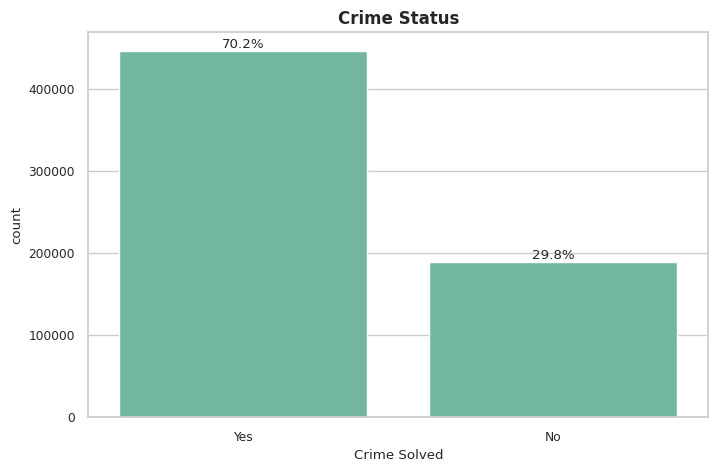

In [ ]:
countplot_with_percentage(ndf, 'Crime Solved')
plt.title('Crime Status', fontsize= 12, fontweight = 'bold')


***Observation :***  
Solved crime - 446950 or 70.22%  
Unsolved - 9082 or 29.78%  

* Most the cases were solved with over 70% outof total, but still there were 30% cases which remain unsolved.

In [ ]:
#Victim Sex
ndf['Victim Sex'].value_counts()

,count
Victim Sex,
Male,492577
Female,143013
Unknown,933


Text(0.5, 1.0, 'Victim Sex Distribution')

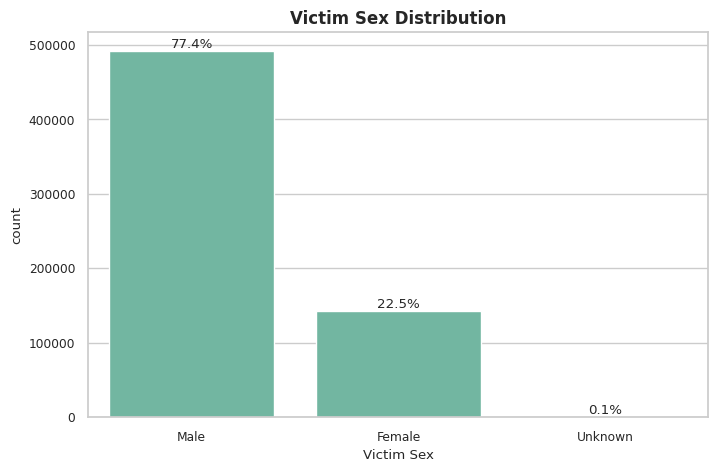

In [ ]:
countplot_with_percentage(ndf, 'Victim Sex')
plt.title('Victim Sex Distribution', fontsize= 12, fontweight = 'bold')


***Observation :***  

`Victim Sex` column that represents the gender of victim provides insights as -  
* Male - 492577 with 77.4%
* Female - 143013 with 22.5%
* Unknown - 933 with 0.1%

Most the victims were male with the highest number of reported crimes whereas female reported victims are low. Some of the unknows can also be seen, it could be gender idenctification issue by the authorites.

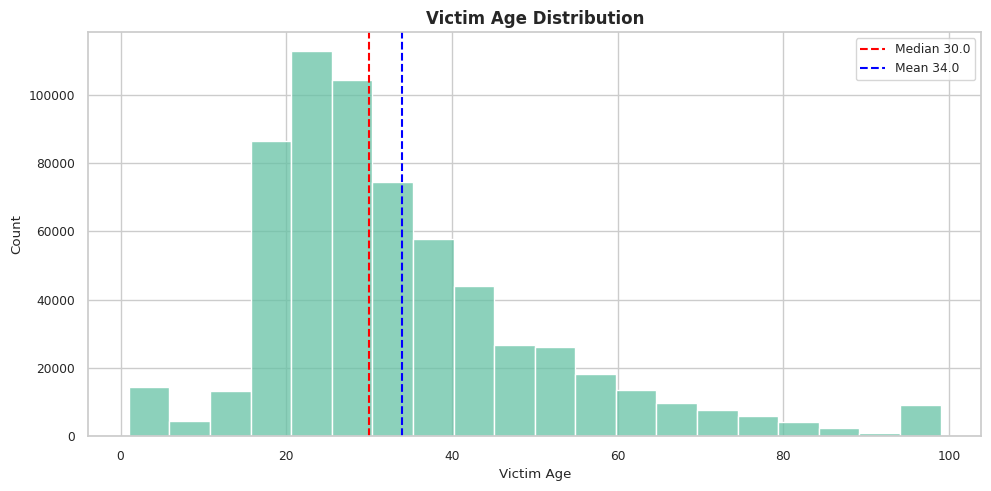

In [ ]:
#Victim Age
plt.figure(figsize=(10,5))
sns.histplot(ndf['Victim Age'], binwidth=5)
plt.axvline(
    ndf['Victim Age'].median(),
    color = 'red',
    linestyle = '--',
    label = f'Median { ndf['Victim Age'].median():.1f}'
)
plt.axvline(ndf['Victim Age'].mean(),
            color = 'blue',
            linestyle = '--',
            label = f'Mean { ndf['Victim Age'].mean():.1f}'
)
plt.title('Victim Age Distribution', fontsize= 12, fontweight = 'bold')

plt.legend()
plt.tight_layout()

***Obsevation :***  
Most victims were between **25 and 30 years** of age. The distribution also shows smaller peaks in the **0–10** age group, indicating reported cases involving infants and young children, as well as in the **95–100** age group, representing elderly victims.  

* Mean - 34 Years
* Median - 30 Years

In [ ]:
#Perpetrator Sex
pd.DataFrame({
    'Count' : ndf['Perpetrator Sex'].value_counts(),
    'Percentage' :ndf['Perpetrator Sex'].value_counts(normalize=True).mul(100).round(2)
}
)

,Count,Percentage
Perpetrator Sex,,
Male,398406,62.59
Unknown,189656,29.80
Female,48461,7.61


Text(0.5, 1.0, 'Perpetrator Sex Distribution')

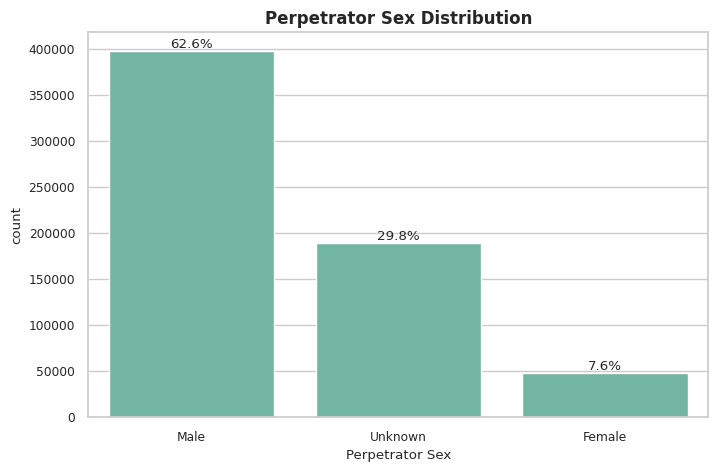

In [ ]:
countplot_with_percentage(ndf, 'Perpetrator Sex')
plt.title('Perpetrator Sex Distribution', fontsize= 12, fontweight = 'bold')


***Observation :***  
the column `Perpetrator Sex` show insights as -  
* Male - 398406 with 62.6%
* Unknown - 189656 with 29.8%
* Female - 48461 with 7.6%  

surprisingly there are huge number of cases where the Perpetrator gender couldnt indentified.  
Also it can clearly be seen that male involvement in crime is much more compare to females.


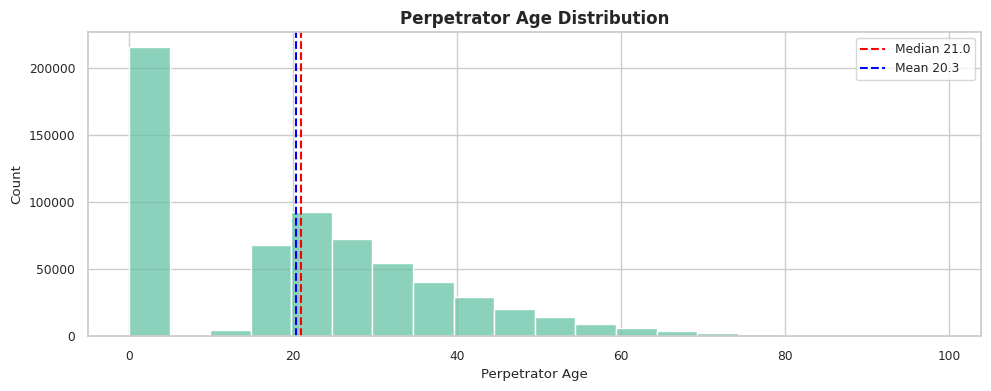

In [ ]:
# Perpetrator Age
plt.figure(figsize=(10,4))
sns.histplot(ndf['Perpetrator Age'], binwidth=5)
plt.axvline(
    ndf['Perpetrator Age'].median(),
    color = 'red',
    linestyle = '--',
    label = f'Median { ndf['Perpetrator Age'].median():.1f}'
)
plt.axvline(ndf['Perpetrator Age'].mean(),
            color = 'blue',
            linestyle = '--',
            label = f'Mean { ndf['Perpetrator Age'].mean():.1f}'
)
plt.title('Perpetrator Age Distribution', fontsize= 12, fontweight = 'bold')

plt.legend()
plt.tight_layout()

***Observation :***  
There are huge number of data where perpetrator age is unknown i.e here it is represented as 0, therefor we can see the large peak in the 0-5.  

**_Interpretation_ :**  
* It is possible that the age indentification or any kind of information about the perpetrator's age was'nt avalable to authorities.  
* Or the case remain unsloved i.e we didnt have any information about the perpetrator.

In [ ]:
pd.DataFrame({
    'Count' : ndf['Relationship'].value_counts().head(),
    'Percentage %' :ndf['Relationship'].value_counts(normalize=True).head().mul(100).round(2)
}
)

,Count,Percentage %
Relationship,,
Unknown,271959,42.73
Acquaintance,125691,19.75
Stranger,96261,15.12
Wife,23165,3.64
Friend,21903,3.44


Text(0.5, 1.0, 'Relationship between Victim and Perpetrator')

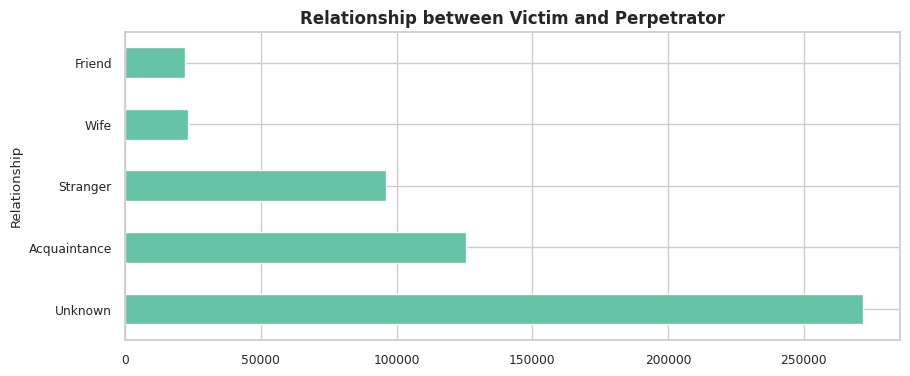

In [ ]:
ndf['Relationship'].value_counts(ascending=False).head().plot(kind = 'barh', figsize=(10,4))
plt.title('Crime Status by the Gender', fontsize= 12, fontweight = 'bold')
plt.title('Relationship between Victim and Perpetrator', fontsize= 12, fontweight = 'bold')


***Observation -***  
The number of those cases are high where the relation between the victim and perpetrator was unknown , but second most is "Acquaintance" with over ~13000 cases.

In [ ]:
ndf['Weapon'].value_counts(ascending=False).head()

,count
Weapon,
Handgun,316463
Knife,94856
Blunt Object,67284
Firearm,46727
Unknown,33039


Text(0.5, 1.0, 'Weapons Used during Crime')

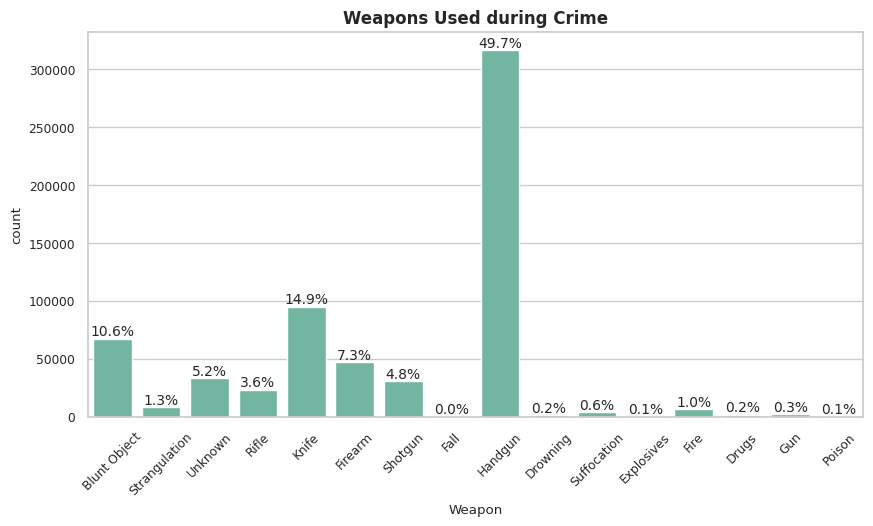

In [ ]:
#weapon
plt.figure(figsize=(10,5))
ax = sns.countplot(data= ndf, x= ndf['Weapon'])
plt.xticks(rotation=45)

for p in ax.patches:
    percentage = 100 * p.get_height() / len(ndf)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)
plt.title('Weapons Used during Crime', fontsize= 12, fontweight = 'bold')


***Observation -***  
Most of the crimes are committed by using any kind of fire-arms and handguns are the most used weapons   
* Handgun - 316463  
* Knife - 94856  
* Blunt Object - 67284  
* Firearm - 46727  
* Unknown - 33039  


Text(0.5, 0.98, 'Crime Status by the Gender')

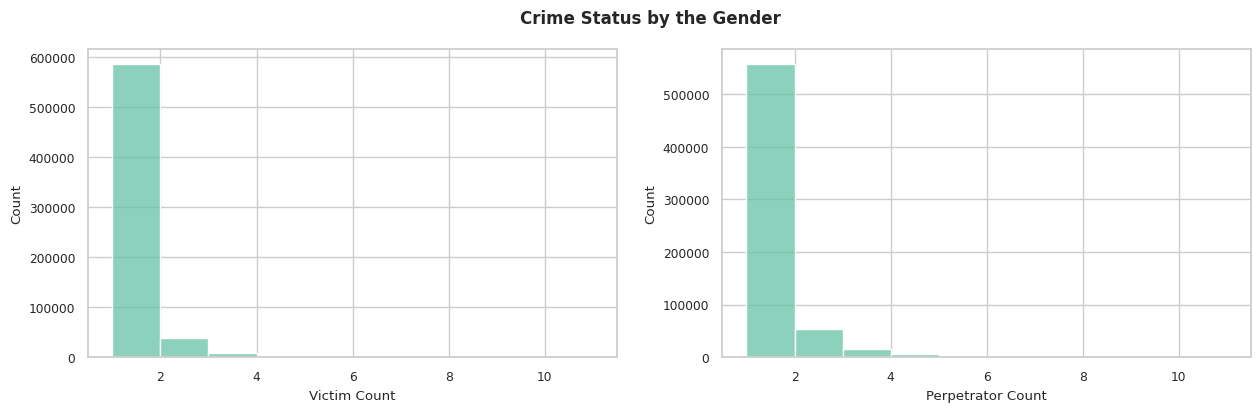

In [ ]:
# Victim Count and Perpetrator Count

fig, ax = plt.subplots(1,2, figsize=(15,4))
sns.histplot(
    data = ndf,
    x= 'Victim Count',
    bins = 10,
    ax = ax[0]
)

sns.histplot(
    data = ndf,
    x= 'Perpetrator Count',
    bins = 10,
    ax = ax[1]
)
fig.suptitle('Crime Status by the Gender', fontsize= 12, fontweight = 'bold')


***Observation -***  
Both Victima and Prepetrator Conuts columns show the same type of results,  
* Victim Counts generally has the 0-2 victime counts most same goes for the Perpetrator counts column

## 3.2 Bivariate Analysis

In [ ]:
pd.crosstab(ndf['Perpetrator Sex'], ndf['Victim Sex'], margins=True)

Victim Sex,Female,Male,Unknown,All
Perpetrator Sex,,,,
Female,10824,37589,48,48461
Male,99160,298968,278,398406
Unknown,33029,156020,607,189656
All,143013,492577,933,636523


**Observation -**  
* The dataset contains around 636,523 total cases, with male victime 492,577 cases that the ~77% of the total cases whereas females show lower cases around 143,013 that's the ~22%.   

* There are 189,656 unsolved cases.

Text(0.5, 1.0, 'Victim Age vs Perpetrator Age')

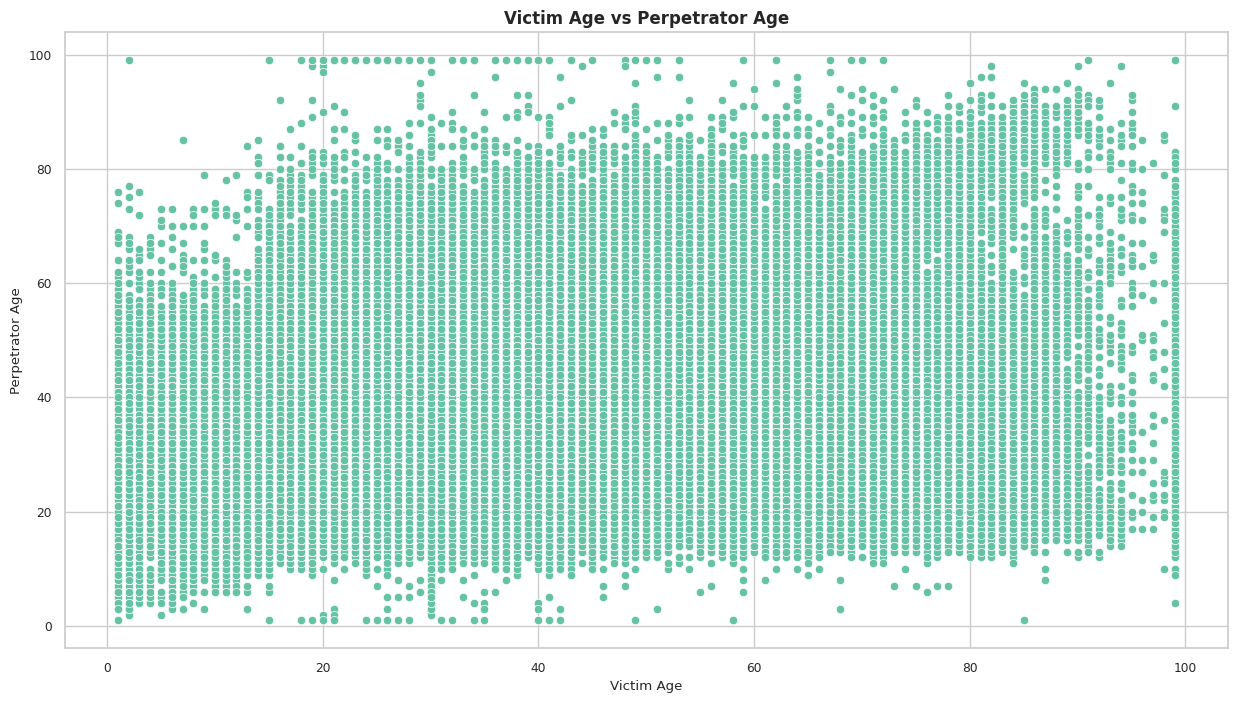

In [ ]:
age_df = ndf[(ndf['Victim Age'] >0) & (ndf['Perpetrator Age'] >0)]

plt.figure(figsize=(15,8))
sns.scatterplot(
    data= age_df,
    x= 'Victim Age',
    y= 'Perpetrator Age'
)
plt.title('Victim Age vs Perpetrator Age', fontsize= 12, fontweight = 'bold')


The scatter plot of victim age versus perpetrator age suggests a weak positive association. However, the wide dispersion of points shows substantial variability, meaning perpetrators of various ages are involved across nearly all victim age groups.

In [ ]:
ptc_solved_crime= pd.crosstab( ndf['Crime Type'], ndf['Crime Solved'], margins=True, normalize=True)*100
print(ptc_solved_crime.round(2))

Crime Solved                   No    Yes     All
Crime Type                                      
Manslaughter by Negligence   0.06   1.37    1.43
Murder or Manslaughter      29.72  68.85   98.57
All                         29.78  70.22  100.00


Text(0.5, 1.0, 'Crime Status by the Crime Type')

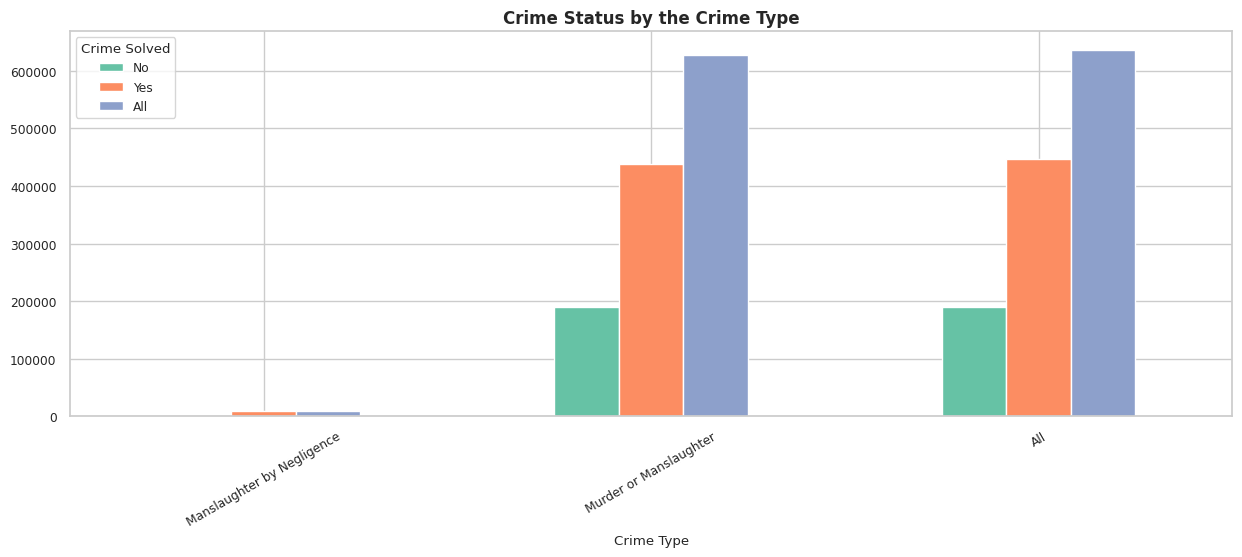

In [ ]:
solved_crime = pd.crosstab( ndf['Crime Type'], ndf['Crime Solved'], margins=True)
solved_crime.plot(
    kind= 'bar',
    figsize= (15,5)
)
plt.xticks(rotation= 30)
plt.title('Crime Status by the Crime Type', fontsize= 12, fontweight = 'bold')


**Observation -**  
* There only two types of Cases  
    * Manslaghuter by Negligence
    * Murder or Manslaghuter  

Manslaghuter by Negligence has very few cases around ~1.43% of the total cases. Whereas Murder cases occupy around 98% of the data.  

* Important observation is that, outoff total cases there are 29% cases whihc are unsloved.

In [ ]:
pd.crosstab(ndf['Weapon'], ndf['Crime Solved'], margins= True).sort_values(by= 'All', ascending= False)

Crime Solved,No,Yes,All
Weapon,,,
All,189573,446950,636523
Handgun,100194,216269,316463
Knife,20168,74688,94856
Blunt Object,15819,51465,67284
Firearm,22433,24294,46727
Unknown,14709,18330,33039
Shotgun,4674,25976,30650
Rifle,3371,19850,23221
Strangulation,3698,4403,8101


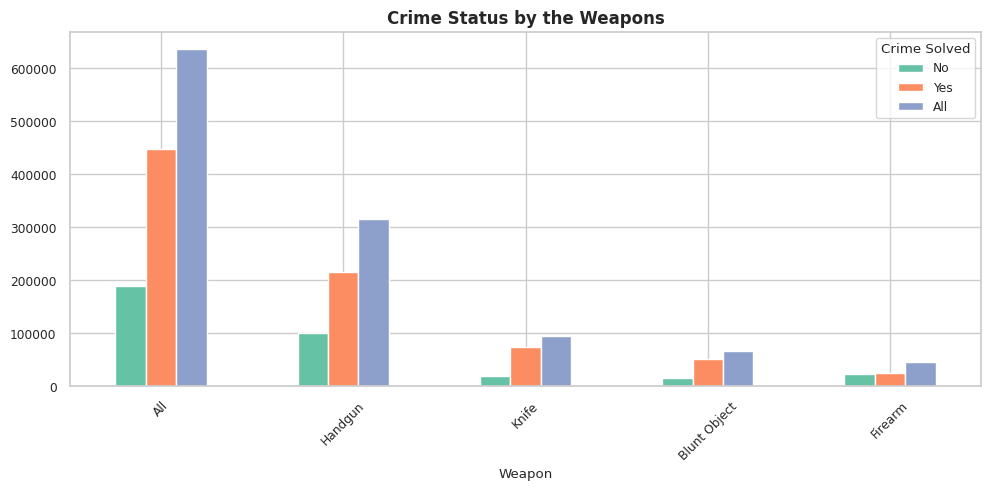

In [ ]:
pd.crosstab(ndf['Weapon'], ndf['Crime Solved'], margins=True).sort_values(by= 'All', ascending= False).head().plot(kind='bar', figsize=(10,5))
plt.xticks(rotation= 45)
plt.title('Crime Status by the Weapons', fontsize= 12, fontweight = 'bold')

plt.tight_layout()
plt.show()

Handgun has the highest rate of crime with over 316,463 cases in which 216,269 are solved but 100,194 reamin unsolved.

Text(0.5, 1.0, 'Crime Status by the Relationship')

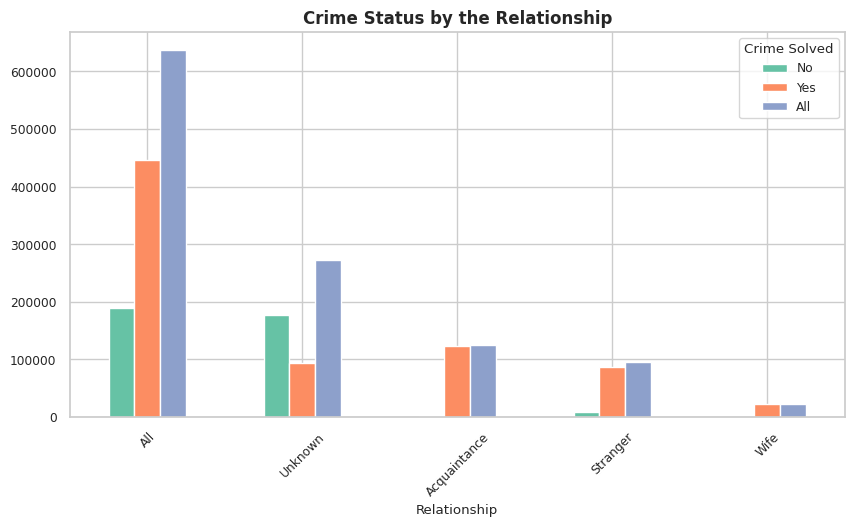

In [ ]:
pd.crosstab(ndf['Relationship'], ndf['Crime Solved'],
            margins= True).sort_values(by= 'All', ascending= False).head().plot(kind='bar', figsize=(10,5))
plt.xticks(rotation= 45)
plt.title('Crime Status by the Relationship', fontsize= 12, fontweight = 'bold')

Unknown has the highest rate of crime reports, i.e there were multiple cases where the exact relationship between the victim and prepetrator was unknown.  

The second most insightfull relation we can see is, Acquaintance that tell the breif story, in most of the cases the accused was somehow related of known by the victims.

In [ ]:
ndf.groupby(['Victim Sex', 'Crime Solved']).size()

Victim Sex  Crime Solved
Female      No               33010
            Yes             110003
Male        No              155956
            Yes             336621
Unknown     No                 607
            Yes                326
dtype: int64

Text(0.5, 1.0, 'Crime Status by the Gender')

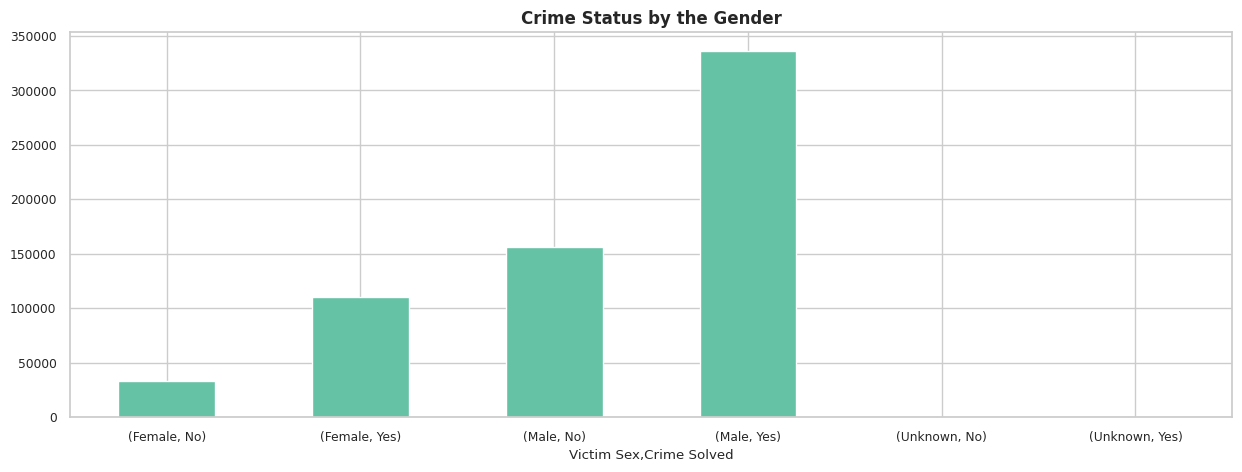

In [ ]:
ndf.groupby(['Victim Sex', 'Crime Solved']).size().plot(kind= 'bar', figsize= (15,5))
plt.xticks(rotation = 0)
plt.title('Crime Status by the Gender', fontsize= 12, fontweight = 'bold')

Male victim involvment is the highest compare to females so it logically obvious that, Male cases has the highest rate of solved crimes

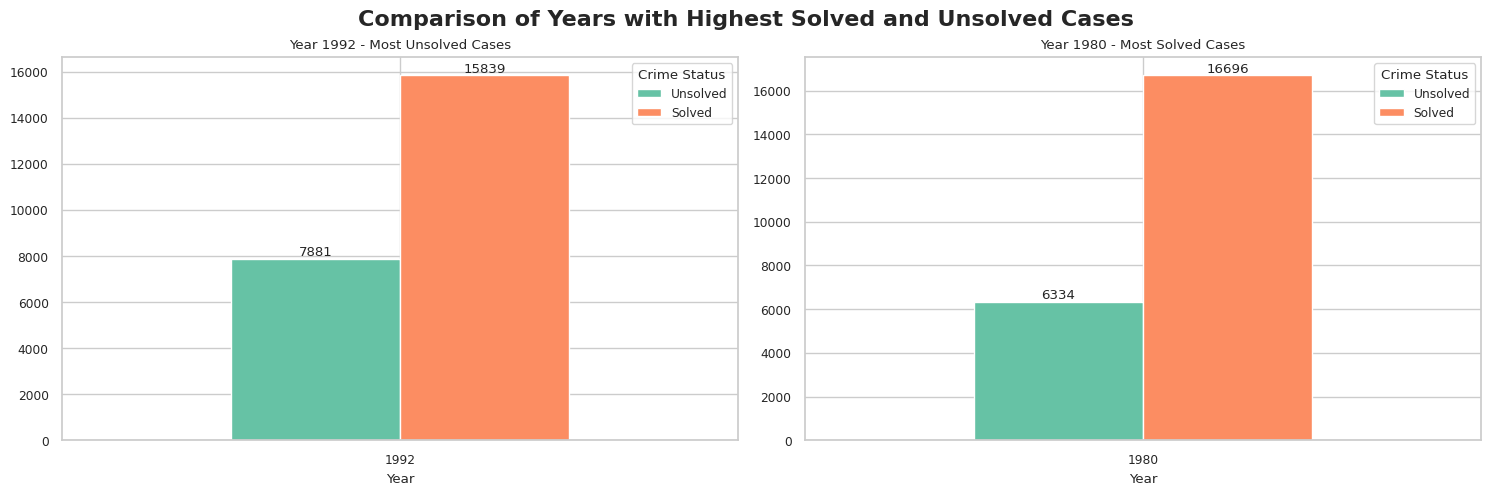

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ct_No = pd.crosstab(ndf['Year'], ndf['Crime Solved']).sort_values(by='No', ascending=False).head(1)
ct_Yes = pd.crosstab(ndf['Year'], ndf['Crime Solved']).sort_values(by='Yes', ascending=False).head(1)

ct_No.plot(kind='bar', ax=ax[0], legend=False)
ct_Yes.plot(kind='bar', ax=ax[1], legend=False)

ax[0].set_title(f"Year {ct_No.index[0]} - Most Unsolved Cases")
ax[1].set_title(f"Year {ct_Yes.index[0]} - Most Solved Cases")

ax[0].set_xticklabels([ct_No.index[0]], rotation=0)
ax[1].set_xticklabels([ct_Yes.index[0]], rotation=0)

ax[0].legend(["Unsolved", "Solved"], title="Crime Status")
ax[1].legend(["Unsolved", "Solved"], title="Crime Status")

for a in ax:
    for container in a.containers:
        a.bar_label(container)


plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("Comparison of Years with Highest Solved and Unsolved Cases",
             fontsize=16,
             fontweight='bold')
plt.show()

* **1992** was the year where most of the cases found unsolved.  
* **1980** was one the most succesfull year where 16,696 case were solved by the authorities.

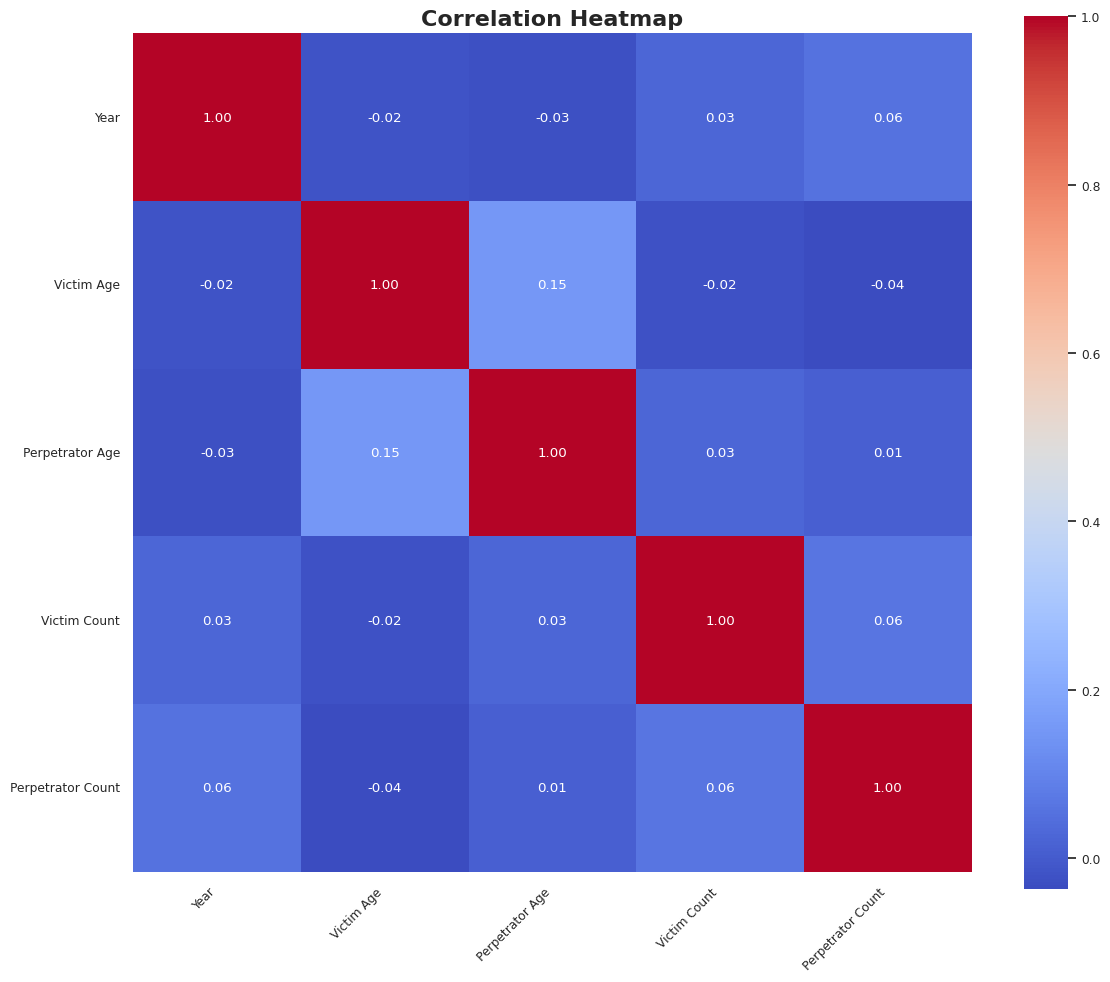

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    ndf.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap", fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

The correlation heatmap indicates that there are no strong linear relationships among the numerical variables in the dataset. The highest correlation (0.15) is observed between Victim Age and Perpetrator Age, suggesting only a weak positive association. Whereas other Variables display the negitive correlation.

## **3.3 Conclusion**

This exploratory data analysis examined homicide records to identify trends and relationships among different variables. The analysis revealed that crime occurrences and case resolution rates varied across years, states, victim demographics, and weapon types. Most numerical variables exhibited very weak correlations, indicating that factors influencing crime are largely categorical rather than numerical. The project also highlighted patterns in victim and perpetrator characteristics, providing useful insights into the dataset.
